In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import os

print("REDD file exists:", os.path.exists("/content/redd_house1_1.csv"))

REDD file exists: True


In [ ]:
import pandas as pd

data = pd.read_csv("/content/redd_house1_1.csv")

print("Dataset loaded!")
print("Rows:", len(data))
print("Columns:", list(data.columns))

Dataset loaded!
Rows: 25839
Columns: ['Unnamed: 0', 'dish washer', 'electric space heater', 'electric stove', 'fridge', 'microwave', 'washer dryer', 'main']


In [ ]:
# Create the true ON/OFF state of the fridge

data["fridge_on"] = (data["fridge"] > 50).astype(int)

print(data["fridge_on"].value_counts())

fridge_on
0    19610
1     6229
Name: count, dtype: int64


In [ ]:
# Look at the fridge power when it is ON
data.loc[data["fridge_on"] == 1, "fridge"].describe()

,fridge
count,6229.000000
mean,203.932895
std,61.610105
min,181.000000
25%,187.000000
50%,191.000000
75%,197.000000
max,2134.000000


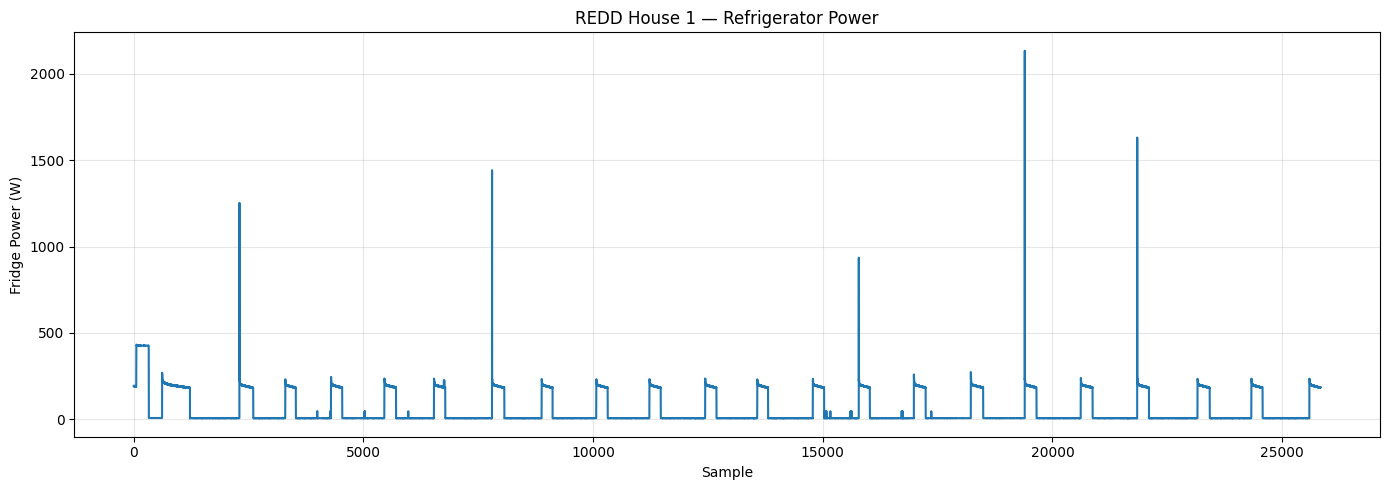

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(data["fridge"])

plt.xlabel("Sample")
plt.ylabel("Fridge Power (W)")
plt.title("REDD House 1 — Refrigerator Power")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Create the input signal for our NILM system
X = data[["main"]].copy()

# Ground truth — kept separately for evaluation
y = data["fridge_on"].copy()

print("Input:", X.shape)
print("Target:", y.shape)

Input: (25839, 1)
Target: (25839,)


NILM — REDD HOUSE 1 — FRIDGE RESULTS
Accuracy : 0.986
Precision: 1.000
Recall   : 0.941
F1 Score : 0.970

Detailed classification report:
              precision    recall  f1-score   support

  Fridge OFF       0.98      1.00      0.99      3954
   Fridge ON       1.00      0.94      0.97      1213

    accuracy                           0.99      5167
   macro avg       0.99      0.97      0.98      5167
weighted avg       0.99      0.99      0.99      5167



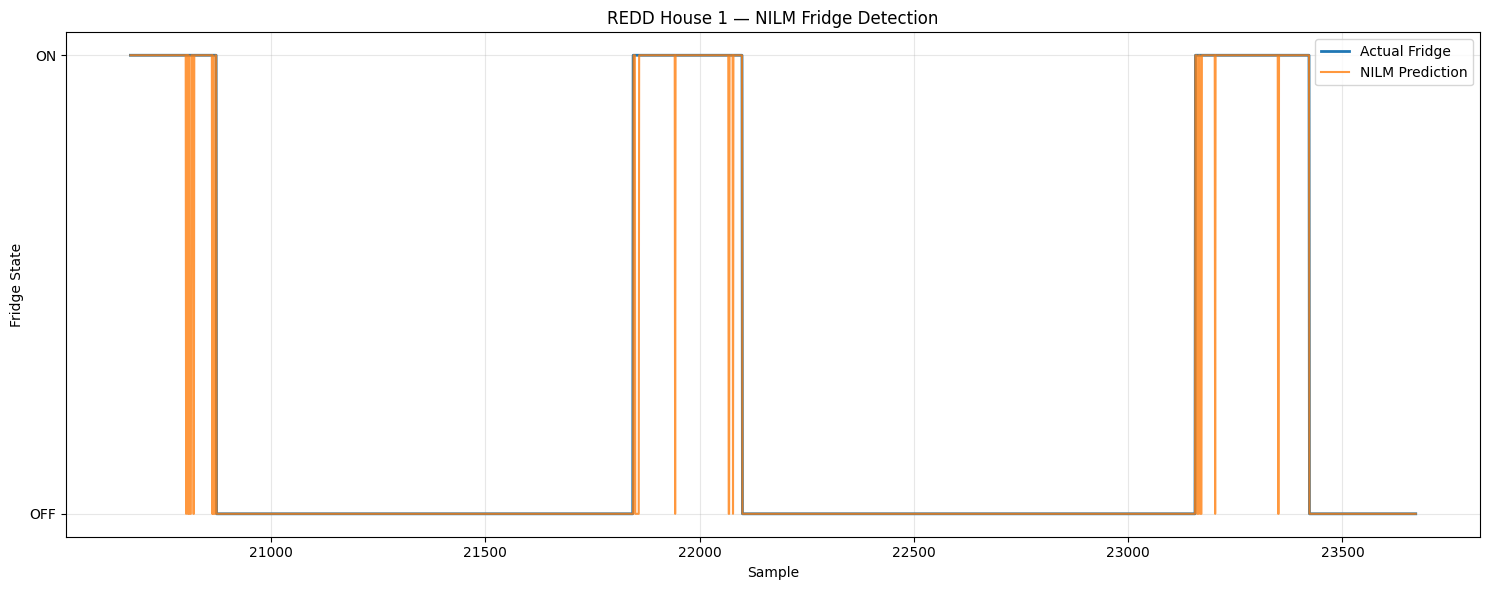


Feature importance:
main            0.309143
main_lag1       0.239138
rolling_mean    0.188907
main_lag2       0.171562
rolling_std     0.072821
main_diff       0.017372
event           0.001058
dtype: float64


In [ ]:
# ============================================================
# FINAL NILM MODEL — REDD House 1 Refrigerator
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# ------------------------------------------------------------
# 1. EVENT DETECTION
# ------------------------------------------------------------

data["power_change"] = data["main"].diff()

EVENT_THRESHOLD = 50  # watts

data["event"] = (
    data["power_change"].abs() > EVENT_THRESHOLD
).astype(int)


# ------------------------------------------------------------
# 2. CREATE FEATURES USING ONLY THE MAIN HOUSE SIGNAL
# ------------------------------------------------------------

data["main_lag1"] = data["main"].shift(1)
data["main_lag2"] = data["main"].shift(2)

data["main_diff"] = data["main"].diff()

data["rolling_mean"] = (
    data["main"].rolling(window=5).mean()
)

data["rolling_std"] = (
    data["main"].rolling(window=5).std()
)

features = [
    "main",
    "main_lag1",
    "main_lag2",
    "main_diff",
    "rolling_mean",
    "rolling_std",
    "event"
]

model_data = data.dropna(subset=features + ["fridge_on"]).copy()


# ------------------------------------------------------------
# 3. CHRONOLOGICAL TRAIN / TEST SPLIT
# ------------------------------------------------------------

split = int(len(model_data) * 0.80)

train = model_data.iloc[:split]
test = model_data.iloc[split:]

X_train = train[features]
y_train = train["fridge_on"]

X_test = test[features]
y_test = test["fridge_on"]


# ------------------------------------------------------------
# 4. TRAIN RANDOM FOREST
# ------------------------------------------------------------

model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train, y_train)


# ------------------------------------------------------------
# 5. PREDICT FRIDGE STATE
# ------------------------------------------------------------

y_pred = model.predict(X_test)


# ------------------------------------------------------------
# 6. EVALUATE
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("=" * 50)
print("NILM — REDD HOUSE 1 — FRIDGE RESULTS")
print("=" * 50)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")

print("\nDetailed classification report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Fridge OFF", "Fridge ON"],
    zero_division=0
))


# ------------------------------------------------------------
# 7. FINAL VISUALIZATION
# ------------------------------------------------------------

plot_points = min(3000, len(test))

plt.figure(figsize=(15, 6))

plt.plot(
    test.index[:plot_points],
    y_test.iloc[:plot_points],
    label="Actual Fridge",
    linewidth=2
)

plt.plot(
    test.index[:plot_points],
    y_pred[:plot_points],
    label="NILM Prediction",
    alpha=0.8
)

plt.xlabel("Sample")
plt.ylabel("Fridge State")
plt.title("REDD House 1 — NILM Fridge Detection")

plt.yticks([0, 1], ["OFF", "ON"])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. FEATURE IMPORTANCE
# ------------------------------------------------------------

importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("\nFeature importance:")
print(importance)

In [ ]:
data["dish washer"].describe()

,dish washer
count,25839.000000
mean,0.056272
std,0.284422
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,9.000000


In [ ]:
data["dish washer"].value_counts().sort_index()
data["dishwasher_on"] = (data["dish washer"] > 0).astype(int)

print(data["dishwasher_on"].value_counts())

dishwasher_on
0    24681
1     1158
Name: count, dtype: int64


In [ ]:
# ============================================================
# NILM MODEL — REDD House 1 — DISHWASHER
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Features from HOUSE TOTAL only
features = [
    "main",
    "main_lag1",
    "main_lag2",
    "main_diff",
    "rolling_mean",
    "rolling_std",
    "event"
]

# Make sure the required features exist
data["main_lag1"] = data["main"].shift(1)
data["main_lag2"] = data["main"].shift(2)
data["main_diff"] = data["main"].diff()
data["rolling_mean"] = data["main"].rolling(5).mean()
data["rolling_std"] = data["main"].rolling(5).std()

data["power_change"] = data["main"].diff()
data["event"] = (data["power_change"].abs() > 50).astype(int)

model_data = data.dropna(subset=features + ["dishwasher_on"]).copy()

# 80% training, 20% testing
split = int(len(model_data) * 0.80)

train = model_data.iloc[:split]
test = model_data.iloc[split:]

X_train = train[features]
y_train = train["dishwasher_on"]

X_test = test[features]
y_test = test["dishwasher_on"]

# Train model
model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train, y_train)

# Predict dishwasher ON/OFF
y_pred = model.predict(X_test)

# Results
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("=" * 50)
print("NILM — REDD HOUSE 1 — DISHWASHER RESULTS")
print("=" * 50)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")

print("\nDetailed classification report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Dishwasher OFF", "Dishwasher ON"],
    zero_division=0
))

NILM — REDD HOUSE 1 — DISHWASHER RESULTS
Accuracy : 0.915
Precision: 0.232
Recall   : 0.525
F1 Score : 0.321

Detailed classification report:
                precision    recall  f1-score   support

Dishwasher OFF       0.98      0.93      0.95      4969
 Dishwasher ON       0.23      0.53      0.32       198

      accuracy                           0.92      5167
     macro avg       0.61      0.73      0.64      5167
  weighted avg       0.95      0.92      0.93      5167



In [14]:
data ["microwave"].describe()

,microwave
count,25839.000000
mean,23.242579
std,169.148501
min,2.000000
25%,4.000000
50%,4.000000
75%,4.000000
max,1597.000000


In [15]:
data["microwave"].value_counts().sort_index()

,count
microwave,
2.0,92
3.0,110
4.0,24093
5.0,1169
21.0,1
...,...
1591.0,5
1593.0,2
1594.0,1


In [16]:
data["microwave_on"] = (data["microwave"] > 50).astype(int)

print(data["microwave_on"].value_counts())

microwave_on
0    25505
1      334
Name: count, dtype: int64


In [18]:
# ============================================================
# NILM MODEL — REDD House 1 — MICROWAVE (CORRECTED)
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

features = [
    "main",
    "main_lag1",
    "main_lag2",
    "main_diff",
    "rolling_mean",
    "rolling_std",
    "event"
]

# Make sure features exist
data["main_lag1"] = data["main"].shift(1)
data["main_lag2"] = data["main"].shift(2)
data["main_diff"] = data["main"].diff()
data["rolling_mean"] = data["main"].rolling(5).mean()
data["rolling_std"] = data["main"].rolling(5).std()
data["power_change"] = data["main"].diff()
data["event"] = (data["power_change"].abs() > 50).astype(int)

model_data = data.dropna(
    subset=features + ["microwave_on"]
).copy()

X = model_data[features]
y = model_data["microwave_on"]

# Stratified split: keeps ON/OFF proportions in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Train Random Forest
model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Results
print("=" * 50)
print("NILM — REDD HOUSE 1 — MICROWAVE RESULTS")
print("=" * 50)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred, zero_division=0):.3f}")
print(f"F1 Score : {f1_score(y_test, y_pred, zero_division=0):.3f}")

print("\nDetailed classification report:")
print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=["Microwave OFF", "Microwave ON"],
    zero_division=0
))

NILM — REDD HOUSE 1 — MICROWAVE RESULTS
Accuracy : 0.998
Precision: 0.983
Recall   : 0.881
F1 Score : 0.929

Detailed classification report:
               precision    recall  f1-score   support

Microwave OFF       1.00      1.00      1.00      5100
 Microwave ON       0.98      0.88      0.93        67

     accuracy                           1.00      5167
    macro avg       0.99      0.94      0.96      5167
 weighted avg       1.00      1.00      1.00      5167

